# 区分別出願エントロピー分析

`output/` フォルダにある集計済み CSV を読み込み、区分別出願件数の **Shannon エントロピー** を計算する。

| 指標 | 意味 |
|---|---|
| `entropy` | Shannon entropy（底2、単位: bits） |
| `entropy_normalized` | `entropy / log2(45)` → 0〜1 に正規化（1 = 全45区分均等） |
| `n_classes_used` | 出願ゼロでない区分の数 |
| `total_applications` | 総出願件数 |

In [1]:
import glob
import os

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

from utils.trademark_utils import calc_entropy

matplotlib.rcParams['font.family'] = 'Meiryo'
print('セットアップ完了')

セットアップ完了


---

## 1. ファイル選択

`output/` フォルダにある CSV ファイルの一覧を表示する。  
`target_filename` に使用するファイル名を入力してから次のセルを実行すること。

In [2]:
csv_files = sorted(glob.glob('output/*.csv'))

if not csv_files:
    raise FileNotFoundError(
        'output/ フォルダに CSV ファイルが見つかりません。'
        ' class_filing_analysis.ipynb でデータを出力してください。'
    )

print('利用可能なファイル一覧:')
for f in csv_files:
    print(' ', os.path.basename(f))

利用可能なファイル一覧:
  class_filing_131094_2018-2020.csv
  class_filing_131094_2020.csv
  class_filing_505187024_2018-2020.csv
  class_filing_709006024_2020.csv


In [3]:
# ===== 使用するファイル名を入力（output/ 以下のファイル名のみ） =====
target_filename = 'class_filing_131094_2018-2020.csv'   # 例: 'class_filing_131094_2020.csv'
# ==================================================================

if target_filename is None:
    raise ValueError(
        'target_filename が未設定です。上のセルで表示されたファイル名を入力してください。'
    )

target_path = os.path.join('output', target_filename)

if not os.path.exists(target_path):
    raise FileNotFoundError(
        f'ファイルが見つかりません: {target_path}\n'
        f'上のセルで表示されたファイル名を確認してください。'
    )

print(f'対象ファイル: {target_path}')

対象ファイル: output\class_filing_131094_2018-2020.csv


---

## 2. データ読み込み

In [4]:
df = pd.read_csv(target_path)

company_name = df['company_name'].iloc[0]
company_id   = df['company_id'].iloc[0]
years        = sorted(df['filing_year'].unique())

print(f'企業名   : {company_name}（ID: {company_id}）')
print(f'出願年   : {years}')
print(f'レコード数: {len(df):,} 件')
df.head()

企業名   : 株式会社サンリオ（ID: 131094）
出願年   : [np.int64(2018), np.int64(2019), np.int64(2020)]
レコード数: 132 件


,company_id,company_name,filing_year,class_number,application_count
0,131094,株式会社サンリオ,2018,1,32
1,131094,株式会社サンリオ,2019,1,21
2,131094,株式会社サンリオ,2020,1,17
3,131094,株式会社サンリオ,2019,2,27
4,131094,株式会社サンリオ,2020,2,20


---

## 3. エントロピー計算

出願年ごとに Shannon entropy を計算する。加えて、全期間（年をまたいで区分別件数を合算したもの）のエントロピーも算出する。  
ファイルが単年データの場合でも、複数年データにも対応している。

In [5]:
rows = []
for year, grp in df.groupby('filing_year'):
    counts = grp.set_index('class_number')['application_count']
    metrics = calc_entropy(counts)
    rows.append({'filing_year': str(year), **metrics})

# 全期間合算（複数年ファイルの場合、年をまたいで区分別件数を合算した上でのエントロピー）
counts_all = df.groupby('class_number')['application_count'].sum()
rows.append({'filing_year': '全期間', **calc_entropy(counts_all)})

df_entropy = pd.DataFrame(rows).reset_index(drop=True)

df_entropy.columns = [
    '出願年', 'エントロピー (bits)', '正規化エントロピー', '使用区分数', '総出願件数'
]

print(f'{company_name} のエントロピー指標')
df_entropy

株式会社サンリオ のエントロピー指標


,出願年,エントロピー (bits),正規化エントロピー,使用区分数,総出願件数
0,2018,5.3348,0.9714,44,1728
1,2019,5.3731,0.9784,44,1696
2,2020,5.3037,0.9657,44,1445
3,全期間,5.3486,0.9739,44,4869


---

## 4. 可視化

正規化エントロピーをゲージバーで表示する。  
値が 1.0 に近いほど全45区分に均等に出願（分散型）、0 に近いほど特定区分に集中（コア集中型）。

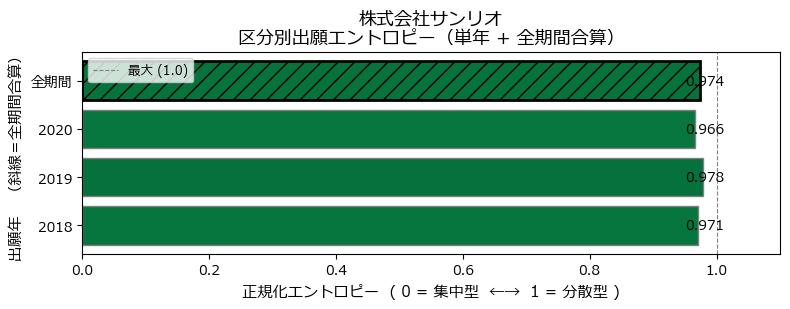

In [6]:
norm_values = df_entropy['正規化エントロピー'].values
filing_years = df_entropy['出願年'].values
is_total = (filing_years == '全期間')

fig, ax = plt.subplots(figsize=(8, max(2, len(norm_values) * 0.8)))

colors = plt.cm.RdYlGn(norm_values)  # 低=赤（集中）、高=緑（分散）
bars = ax.barh(
    filing_years.astype(str), norm_values, color=colors,
    edgecolor=['black' if t else 'grey' for t in is_total],
    linewidth=[2 if t else 1 for t in is_total],
    hatch=['//' if t else None for t in is_total],
)

# 最大値の基準線
ax.axvline(x=1.0, color='grey', linestyle='--', linewidth=0.8, label='最大 (1.0)')

# バー内に数値を表示
for bar, val in zip(bars, norm_values):
    ax.text(
        min(val + 0.02, 0.95), bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}', va='center', fontsize=10
    )

ax.set_xlim(0, 1.1)
ax.set_xlabel('正規化エントロピー  ( 0 = 集中型  ←→  1 = 分散型 )', fontsize=11)
ax.set_ylabel('出願年　（斜線＝全期間合算）', fontsize=11)
ax.set_title(f'{company_name}\n区分別出願エントロピー（単年 + 全期間合算）', fontsize=13)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()